<a href="https://colab.research.google.com/github/RhythmRhythmm/Exploratory-Data-Analysis-on-Store-Data-set/blob/main/EY_GDS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [38]:
timings = pd.read_csv("/content/signal_timings_data.csv")
timings

,Intersection,Green_Light_Duration,Red_Light_Duration
0,Intersection_1,107,87
1,Intersection_2,41,47
2,Intersection_3,43,119
3,Intersection_4,111,115
4,Intersection_5,56,85
5,Intersection_6,100,98
6,Intersection_7,77,41
7,Intersection_8,51,49
8,Intersection_9,50,41
9,Intersection_10,72,55


In [39]:
timings['Green_Light_Duration'].mean()


70.8

In [40]:
timings['Red_Light_Duration'].mean()

73.7

In [41]:
traffic = pd.read_csv("/content/traffic_flow_data.csv")
traffic

,Intersection,Hour,Vehicle_Type,Vehicle_Count
0,Intersection_6,20,Car,357
1,Intersection_1,4,Public Transport,308
2,Intersection_4,16,Two-Wheeler,382
3,Intersection_4,3,Company Bus,207
4,Intersection_8,7,Public Transport,59
...,...,...,...,...
235,Intersection_2,5,Company Bus,74
236,Intersection_1,8,Public Transport,144
237,Intersection_4,11,Company Bus,436
238,Intersection_9,14,Company Bus,389


In [42]:
traffic['Vehicle_Count'].sum()

65767

In [43]:
# Merge datasets on Intersection
merged_df = pd.merge(traffic, timings, on='Intersection', how='inner')

# Overview of the data
print(merged_df)

       Intersection  Hour      Vehicle_Type  Vehicle_Count  \
0    Intersection_6    20               Car            357   
1    Intersection_1     4  Public Transport            308   
2    Intersection_4    16       Two-Wheeler            382   
3    Intersection_4     3       Company Bus            207   
4    Intersection_8     7  Public Transport             59   
..              ...   ...               ...            ...   
235  Intersection_2     5       Company Bus             74   
236  Intersection_1     8  Public Transport            144   
237  Intersection_4    11       Company Bus            436   
238  Intersection_9    14       Company Bus            389   
239  Intersection_9     0       Company Bus            437   

     Green_Light_Duration  Red_Light_Duration  
0                     100                  98  
1                     107                  87  
2                     111                 115  
3                     111                 115  
4              

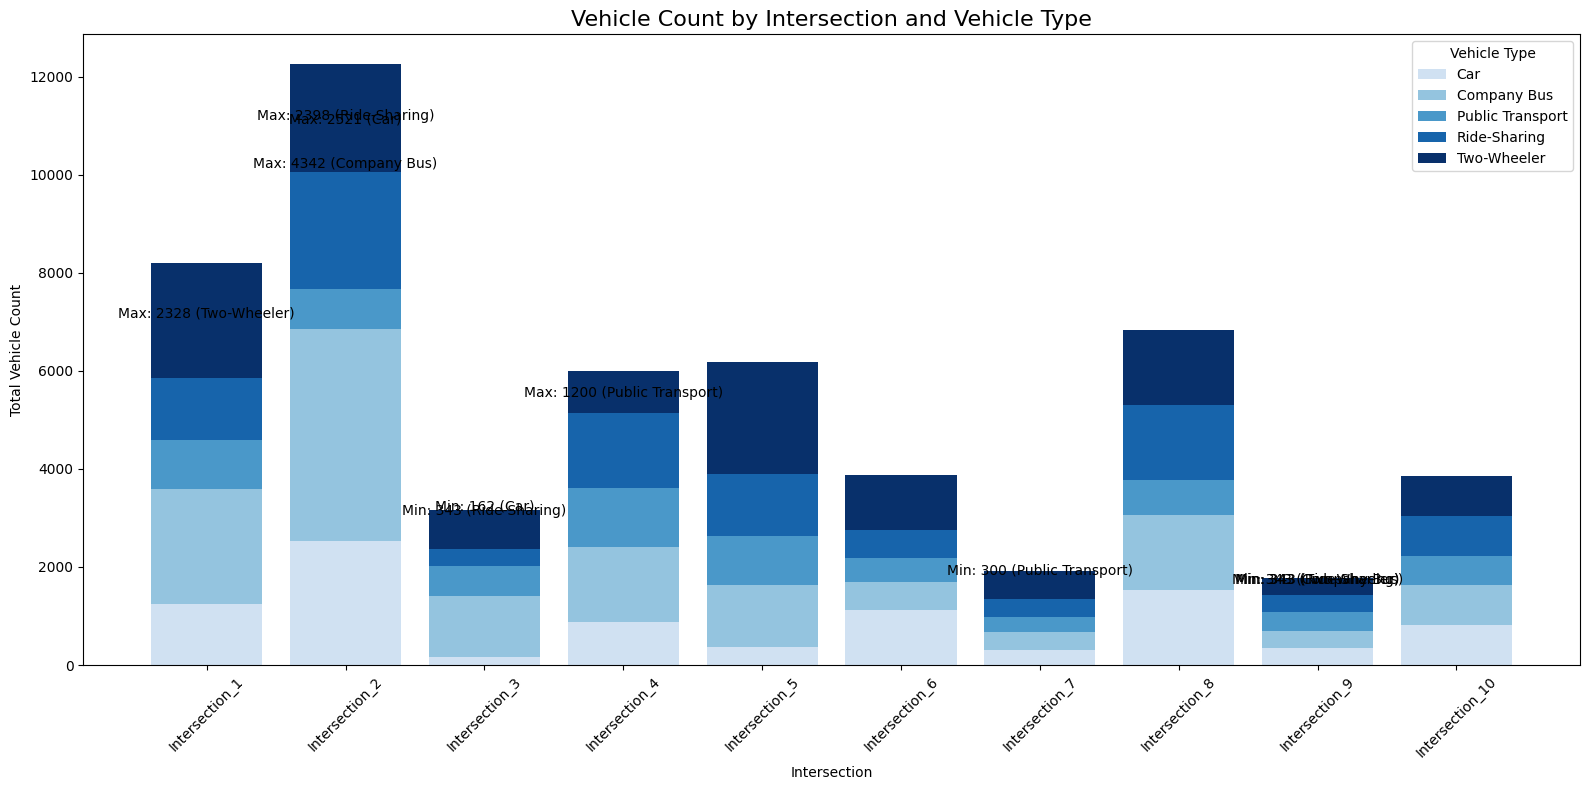

In [51]:
import matplotlib.cm as cm
fig, ax = plt.subplots(figsize=(16, 8))
bar_width = 0.6

# Create a Blues color palette
categories = ["Car", "Company Bus", "Public Transport", "Ride-Sharing", "Two-Wheeler"]
colors = cm.Blues(np.linspace(0.2, 1, len(categories)))  # Generate a blue gradient

# Plot stacked bar chart with color palette
bottom_values = np.zeros(len(df))
for i, category in enumerate(categories):
    ax.bar(df["Intersection"], df[category], bottom=bottom_values, label=category, color=colors[i])
    bottom_values += df[category]

# Add annotations for max and min values
for i, intersection in enumerate(df["Intersection"]):
    for category in categories:
        value = df[category][i]
        max_value = df[category].max()
        min_value = df[category].min()
        if value == max_value:
            ax.text(i, bottom_values[i] - value / 2, f"Max: {value} ({category})", ha='center', va='bottom', fontsize=10, color='black')
        elif value == min_value:
            ax.text(i, bottom_values[i] - value / 2, f"Min: {value} ({category})", ha='center', va='bottom', fontsize=10, color='black')

# Customize plot
ax.set_title("Vehicle Count by Intersection and Vehicle Type", fontsize=16)
ax.set_xlabel("Intersection")
ax.set_ylabel("Total Vehicle Count")
ax.legend(title="Vehicle Type")
plt.xticks(rotation=45)
plt.tight_layout()

# Show plot
plt.show()


<ipython-input-45-5b4ea0e672c5>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Hour', y='Vehicle_Count', data=time_trend, palette='Blues')


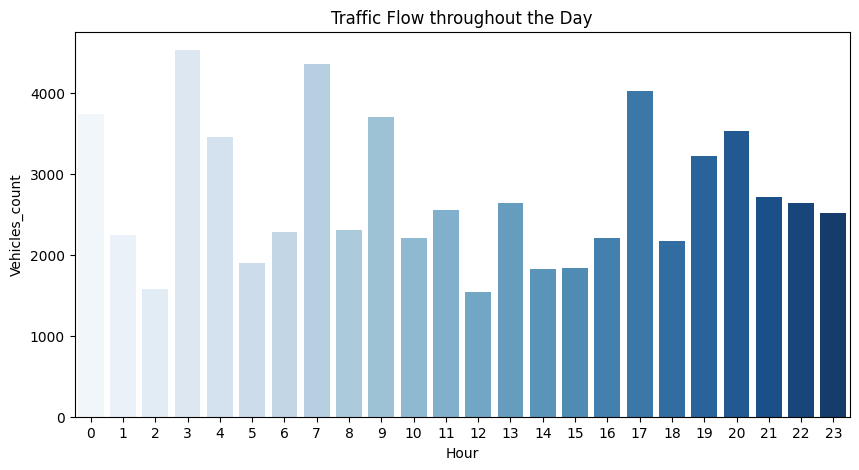

In [45]:
time_trend = merged_df.groupby('Hour')['Vehicle_Count'].sum().reset_index()

# Plot traffic trend
plt.figure(figsize=(10, 5))
sns.barplot(x='Hour', y='Vehicle_Count', data=time_trend, palette='Blues')
plt.title("Traffic Flow throughout the Day")
plt.xlabel("Hour")
plt.ylabel("Vehicles_count")
plt.show()


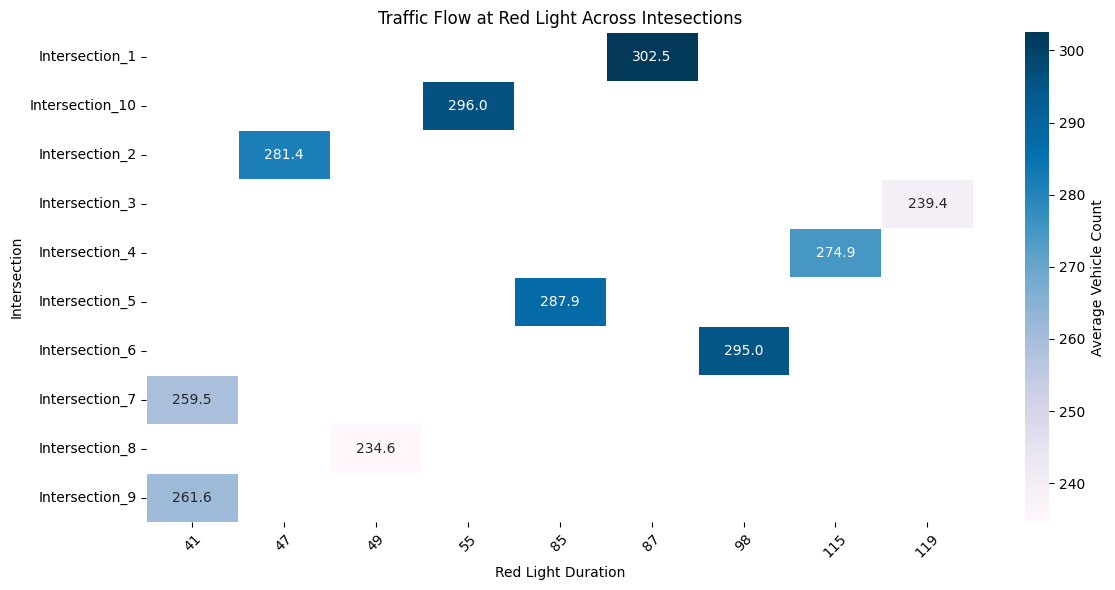

In [46]:
pivot_table = merged_df.pivot_table(index='Intersection', columns='Red_Light_Duration', values='Vehicle_Count', aggfunc='mean')

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table, cmap='PuBu', annot=True, fmt=".1f", linewidths=0.5, cbar_kws={'label': 'Average Vehicle Count'})

plt.title("Traffic Flow at Red Light Across Intesections")
plt.xlabel("Red Light Duration")
plt.ylabel("Intersection")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



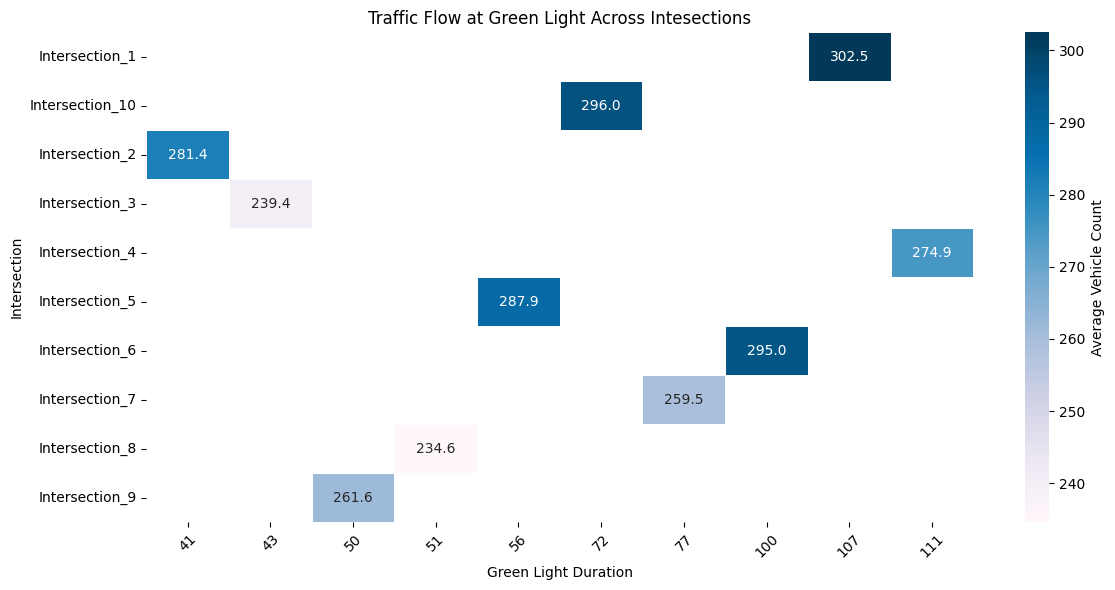

In [47]:
pivot_table = merged_df.pivot_table(index='Intersection', columns='Green_Light_Duration', values='Vehicle_Count', aggfunc='mean')
plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table, cmap='PuBu', annot=True, fmt=".1f", linewidths=0.5, cbar_kws={'label': 'Average Vehicle Count'})

plt.title("Traffic Flow at Green Light Across Intesections")
plt.xlabel("Green Light Duration")
plt.ylabel("Intersection")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
